<a href="https://colab.research.google.com/github/yooli34/brain-tumor-grade-detection/blob/main/VGG16_%5BBaseline_and_Improved_Models%5D_brain_tumor_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Baseline - Model


In [ ]:
!unzip -q /content/drive/MyDrive/MU-Glioma-Post-Sliced-5.zip -d /content

In [ ]:
# set up libraries
!pip install -q nibabel imageio seaborn matplotlib scikit-learn scipy scikit-image pandas pillow
!pip install -q torch torchvision
!pip install tf-keras-vis tensorflow


import os
import keras
from keras.models import Sequential
from keras.layers import Dense, Conv2D, MaxPool2D, Flatten
from keras.applications.vgg16 import VGG16
from keras.applications.vgg16 import preprocess_input
import random
from glob import glob
from pathlib import Path

import numpy as np
import pandas as pd
import scipy.ndimage
from scipy import stats

import torch
from torch import nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, recall_score, accuracy_score, precision_score, f1_score, precision_recall_fscore_support, multilabel_confusion_matrix
from sklearn.preprocessing import LabelEncoder, StandardScaler

import skimage
import imageio
import seaborn as sns
from PIL import Image
import matplotlib.pyplot as plt
%matplotlib inline

import nibabel as nib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.5/52.5 kB 5.2 MB/s eta 0:00:00


In [ ]:
# Set constants
ROOT_IMG_DIR = '/content/MU-Glioma-Post-Sliced-5'
METADATA = '/content/drive/MyDrive/csv_data/tumor_metadata_clean.csv'

PID = 'Patient_ID'
BT_GRADE = 'Grade of Primary Brain Tumor'

IMG_SIZE = 224
BATCH_SIZE = 16
SEED = None

In [ ]:
# read the metadata
md = pd.read_csv(METADATA)
# create a lookup table for each patient and their brain tumor grade
grade_lookup = dict(zip(md[PID], md[BT_GRADE]))

rows = []
files = sorted(Path(ROOT_IMG_DIR).iterdir())

# create a dataframe for the file hierarchy (Patients, timepoint, modality, image) and match with the grade
for patients in files:
  patient_id = patients.name
  grade = grade_lookup.get(patient_id)
  for timepoint in sorted(patients.iterdir()):
    for modalities in sorted(timepoint.iterdir()):
      if not modalities.is_dir():
        continue
      if "t1c" not in modalities.name.lower():
        continue
      for img in sorted(modalities.glob("slice_*.png")):
          rows.append({
              "image_path": str(img),
              "patient_id": patient_id,
              "timepoint":  timepoint.name,
              "modality":   modalities.name,
              "grade":      grade,
              "slice_name": img.stem
          })

df = pd.DataFrame(rows)
print("Total image rows:", len(df))
display(df.head())

Total image rows: 2970


,image_path,patient_id,timepoint,modality,grade,slice_name
0,/content/MU-Glioma-Post-Sliced-5/PatientID_000...,PatientID_0003,Timepoint_1,PatientID_0003_Timepoint_1_brain_t1c,4,slice_+1
1,/content/MU-Glioma-Post-Sliced-5/PatientID_000...,PatientID_0003,Timepoint_1,PatientID_0003_Timepoint_1_brain_t1c,4,slice_+2
2,/content/MU-Glioma-Post-Sliced-5/PatientID_000...,PatientID_0003,Timepoint_1,PatientID_0003_Timepoint_1_brain_t1c,4,slice_-1
3,/content/MU-Glioma-Post-Sliced-5/PatientID_000...,PatientID_0003,Timepoint_1,PatientID_0003_Timepoint_1_brain_t1c,4,slice_-2
4,/content/MU-Glioma-Post-Sliced-5/PatientID_000...,PatientID_0003,Timepoint_1,PatientID_0003_Timepoint_1_brain_t1c,4,slice_0


In [ ]:
# check if missing
print("Missing patient IDs:", df["patient_id"].isna().sum())
print("Missing timepoints:", df["timepoint"].isna().sum())
print("Missing modalities:", df["modality"].isna().sum())
print("Missing grades:", df["grade"].isna().sum())

Missing patient IDs: 0
Missing timepoints: 0
Missing modalities: 0
Missing grades: 0


# Training Notes
##Intial Testing:
### Batch Size
Initially started with a batch size of 16.
### EPOCH RATE
Tested 15, 20, 30. 15 maintained accuracy of 83-84% when tested with a batch of 16. 20 achieved accuracy of ~87%. 30 achieved accuracy of 81-83%.
### Train, Test, Val Split
70%, 15%, 15%

# Split Up the Data for Training and Testing
We split up the data by patients so that we don't lose/mix-up any image slices when we are training.



In [ ]:
# split the training up by patient
patients = sorted(df["patient_id"].unique())

train_patients, temp_patients = train_test_split(
    patients, test_size=0.30, random_state = SEED)
val_patients, test_patients = train_test_split(
    temp_patients, test_size=0.50, random_state = SEED)

train_df = df[df["patient_id"].isin(train_patients)].copy()
val_df = df[df["patient_id"].isin(val_patients)].copy()
test_df = df[df["patient_id"].isin(test_patients)].copy()

print(f"Train patients: {train_df["patient_id"].nunique()}, Val: {val_df["patient_id"].nunique()}, Test: {test_df["patient_id"].nunique()}")
print(f"Train slices: {len(train_df)}, Val: {len(val_df)}, Test: {len(test_df)}")


Train patients: 142, Val: 30, Test: 31
Train slices: 2125, Val: 455, Test: 390


# Data Augmentation

In [ ]:
# rename grades to explicitly say "grade_#"
grade_to_class = {1: 0, 2: 1, 3: 2, 4: 3}

for split_df in [train_df, val_df, test_df]:
    split_df["class_id"] = split_df["grade"].map(grade_to_class)

class_names = ["grade_1", "grade_2", "grade_3", "grade_4"]


# V1 Baseline Model

In [ ]:
import tensorflow as tf

# since VGG-16 uses 224x224 RGB images, we must convert and resize the pngs
def load_img(path, label):
  img = tf.io.read_file(path)
  img = tf.image.decode_png(img, channels=1)
  img = tf.image.grayscale_to_rgb(img)
  img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))
  img = tf.cast(img, tf.float32)
  return img, label

train_ds = tf.data.Dataset.from_tensor_slices((
    train_df["image_path"].values, train_df["class_id"].values
))
val_ds = tf.data.Dataset.from_tensor_slices((
    val_df["image_path"].values, val_df["class_id"].values
))
test_ds = tf.data.Dataset.from_tensor_slices((
    test_df["image_path"].values, test_df["class_id"].values
))

for images, labels in train_ds.take(1):
  print("Label:", labels.numpy())

train_ds = train_ds.shuffle(len(train_df), reshuffle_each_iteration=True).map(load_img).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
val_ds = val_ds.map(load_img).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
test_ds = test_ds.map(load_img).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

In [ ]:
# visualize each inidividual slice
images, labels = next(iter(train_ds))

sample_img   = images[0]
sample_label = int(labels[0])
first_row    = train_df.iloc[0]
patient_id   = first_row["patient_id"]
timepoint    = first_row["timepoint"]

patient_slices = train_df[
    (train_df["patient_id"] == patient_id) &
    (train_df["timepoint"]  == timepoint)
].sort_values("slice_name")
fig, axes = plt.subplots(1, len(patient_slices), figsize=(15, 4), facecolor="black")

for ax, (_, row) in zip(axes, patient_slices.iterrows()):
    # load png
    img = tf.io.read_file(row["image_path"])
    img = tf.image.decode_png(img, channels=1)
    img = tf.image.grayscale_to_rgb(img)
    img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))
    img = tf.cast(img, tf.float32) / 255.0

    ax.imshow(img.numpy())
    ax.set_title(row["slice_name"], color="white", fontsize=11)
    ax.axis("off")

fig.suptitle(
    f"{patient_id}  |  {timepoint}  |  {class_names[sample_label]}",
    color="white", fontsize=13
)
plt.tight_layout()
plt.show()

In [ ]:
## Data Augmentation

In [ ]:
import keras
from keras import layers

augment_img = keras.Sequential([
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
    layers.RandomContrast(0.1)
])

## Weights

In [ ]:
from sklearn.utils import compute_class_weight
# We need to add weights for training to fix the class imbalance
classes = np.array([0, 1, 2, 3])
class_counts = compute_class_weight(class_weight="balanced",classes=classes,y=train_df["class_id"])
weight = dict(zip(classes, class_counts))
class_weights = tf.constant(class_counts, dtype=tf.float32)
print(f"class counts: {weight}")

def cross_entropy_weight(y_true, y_pred):
    y_true = tf.cast(y_true, tf.int32)
    loss = tf.keras.losses.sparse_categorical_crossentropy(y_true, y_pred)

    # get weight for each label
    sample_weights = tf.gather(class_weights, y_true)

    # multiply loss by class weight
    weighted_loss = loss * sample_weights

    return weighted_loss

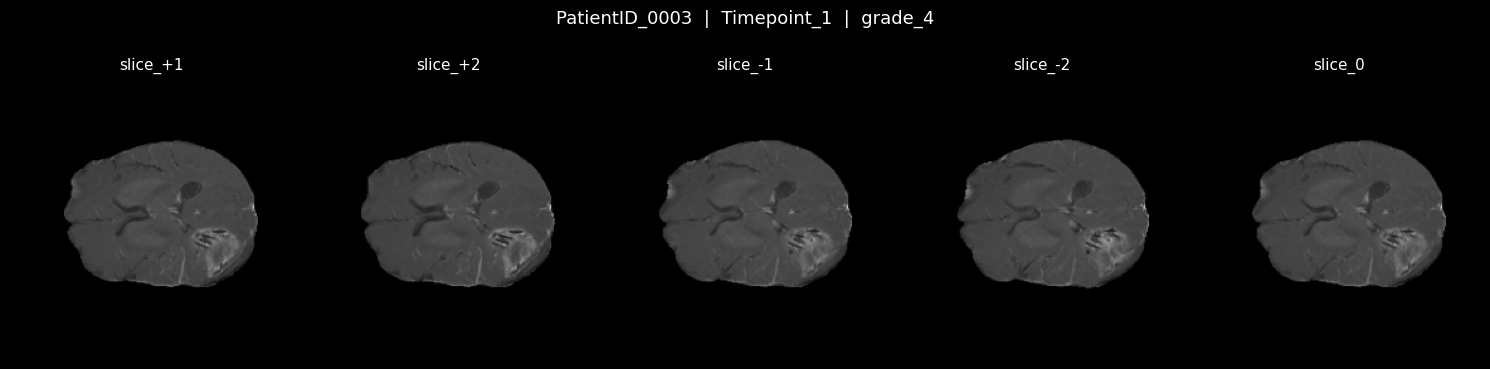

In [ ]:
# visualize each inidividual slice
images, labels = next(iter(train_ds))

sample_img   = images[0]
sample_label = int(labels[0])
first_row    = train_df.iloc[0]
patient_id   = first_row["patient_id"]
timepoint    = first_row["timepoint"]

patient_slices = train_df[
    (train_df["patient_id"] == patient_id) &
    (train_df["timepoint"]  == timepoint)
].sort_values("slice_name")
fig, axes = plt.subplots(1, len(patient_slices), figsize=(15, 4), facecolor="black")

for ax, (_, row) in zip(axes, patient_slices.iterrows()):
    # load png
    img = tf.io.read_file(row["image_path"])
    img = tf.image.decode_png(img, channels=1)
    img = tf.image.grayscale_to_rgb(img)
    img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))
    img = tf.cast(img, tf.float32) / 255.0

    ax.imshow(img.numpy())
    ax.set_title(row["slice_name"], color="white", fontsize=11)
    ax.axis("off")

fig.suptitle(
    f"{patient_id}  |  {timepoint}  |  {class_names[sample_label]}",
    color="white", fontsize=13
)
plt.tight_layout()
plt.show()

## Define VGG-16 Model

In [ ]:
# define the VGG16 model
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3))
base_model.trainable = False

inputs  = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = augment_img(inputs)
x = preprocess_input(x)
x = base_model(x, training=False)
x = keras.layers.GlobalAveragePooling2D()(x)
x = keras.layers.Dropout(0.2)(x)
outputs = layers.Dense(4, activation='softmax')(x)

model = keras.Model(inputs, outputs)
model.summary()

## Hyperparameter tuning

In [ ]:
NUM_EPOCH = 20
model.compile(
    optimizer=keras.optimizers.Adam(1e-4),
    loss=cross_entropy_weight,
    metrics=["accuracy"]
)
history = model.fit(train_ds, validation_data=val_ds, epochs=NUM_EPOCH)
model.evaluate(test_ds)

In [ ]:
# get the values from the test
y_true = []
y_pred = []

for images, labels in test_ds:
    y_true.extend(labels.numpy())
    y_pred.extend(model.predict(images))

y_true = np.array(y_true)
y_pred = np.argmax(np.array(y_pred), axis=1)

## Scores

In [ ]:
import numpy as np

# f1 score calculation
f1score = f1_score(y_true, y_pred, average='weighted')
print(f"F1 Score:{f1score}")

acc_score = accuracy_score(y_true, y_pred)
print(f"Accuracy score: {acc_score}")

prec_score = precision_score(y_true, y_pred, average='weighted', zero_division=1)
print(f"Precision score: {prec_score}")

rec_score = recall_score(y_true, y_pred, average='weighted', zero_division=1)
print(f"Recall score: {rec_score}")

print("\n")

from sklearn.metrics import classification_report

#classifcation report for e grade
print(classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    zero_division=0
))


## Confusion Matrix

In [ ]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()


In [ ]:
# Plot the loss
plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()

# Plot the accuracy curve
plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.show()

#Summary of Findings

## What worked best and why?
Testing the VGG-16 model with 20 EPOCH worked best overall for training because it maintained a high accuracy of ~86-87%.
## What didn’t help
What could be improved on would be adjusting the data augmentation values to increase variability for the classes with low data.
## What model will you likely submit for final report
For the final report, the model we will likely submit would be the VGG-19 model, since it is shown to have the best performance in image classification by maintaining the highest overall accuracy when training.



# V5 Refined Model


## (Updated) Image Visuallization
I updated the visualizations to determine the tumor by slice and modalities instead of just the grade.

In [ ]:
import tensorflow as tf

# since VGG-16 uses 224x224 RGB images, we must convert and resize the pngs
def load_img(path, label):
  img = tf.io.read_file(path)
  img = tf.image.decode_png(img, channels=1)
  img = tf.image.grayscale_to_rgb(img)
  img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))
  img = tf.cast(img, tf.float32)
  return img, label

train_ds = tf.data.Dataset.from_tensor_slices((
    train_df["image_path"].values, train_df["class_id"].values
))
val_ds = tf.data.Dataset.from_tensor_slices((
    val_df["image_path"].values, val_df["class_id"].values
))
test_ds = tf.data.Dataset.from_tensor_slices((
    test_df["image_path"].values, test_df["class_id"].values
))

for images, labels in train_ds.take(1):
  print("Label:", labels.numpy())

train_ds = train_ds.shuffle(len(train_df), reshuffle_each_iteration=True).map(load_img).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
val_ds = val_ds.map(load_img).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
test_ds = test_ds.map(load_img).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

Label: 3


## (New) Weights
I added Median Frequency Balancing weiights to deal with the class imbalances


In [ ]:
import tensorflow as tf

# We need to add weights for training to fix the class imbalance
patient_labels = train_df.drop_duplicates("patient_id")[["patient_id", "grade"]]

class_counts = patient_labels["grade"].value_counts().to_dict()
print("patient + grade class counts:", class_counts)
# Median Freq Balancing
def compute_mfb_weights(class_counts):
  counts = np.array(list(class_counts.values()), dtype=float)
  median_freq = np.median(counts)
  weights = {}
  for cls, count in class_counts.items():
      weights[cls] = median_freq / count
  return weights

mfb_weights = compute_mfb_weights(class_counts)
print("MFB weights:", mfb_weights)

class_weights = tf.constant(
    [mfb_weights[i] for i in sorted(mfb_weights.keys())],
    dtype=tf.float32
)

def cross_entropy_weight(y_true, y_pred):
    y_true  = tf.cast(y_true, tf.int32)
    loss = tf.keras.losses.sparse_categorical_crossentropy(y_true, y_pred)
    weights = tf.gather(class_weights, y_true)
    return tf.reduce_mean(loss * weights)

patient + grade class counts: {4: 117, 2: 18, 3: 4, 1: 3}
MFB weights: {4: np.float64(0.09401709401709402), 2: np.float64(0.6111111111111112), 3: np.float64(2.75), 1: np.float64(3.6666666666666665)}


## Image Augmentation

In [ ]:
import keras
from keras import layers

augment_img = keras.Sequential([
    layers.RandomRotation(0.3),
    layers.RandomZoom(0.2),
    layers.RandomContrast(0.1),
    layers.RandomTranslation(0.1, 0.1),
    layers.RandomFlip("horizontal"),
    layers.RandomFlip("vertical")
])

## Define VGG-16 Model

In [ ]:
# define the VGG16 model
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3))
base_model.trainable = True
for layer in base_model.layers[:-4]:
    layer.trainable = False

inputs  = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = augment_img(inputs)
x = preprocess_input(x)
x = base_model(x, training=False)
x = keras.layers.GlobalAveragePooling2D()(x)
x = keras.layers.Dropout(0.2)(x)
outputs = layers.Dense(4, activation='softmax')(x)

model = keras.Model(inputs, outputs)
model.summary()

##Hyperparameter Tuning

In [ ]:
# Hyperparameter tuning
NUM_EPOCH = 15
model.compile(
    optimizer=keras.optimizers.Adam(1e-5),
    loss=cross_entropy_weight,
    metrics=["accuracy"]
)
history = model.fit(train_ds, validation_data=val_ds, epochs=NUM_EPOCH)
model.evaluate(test_ds)

In [ ]:
# get the values from the test
y_true = []
y_pred = []

for images, labels in test_ds:
    y_true.extend(labels.numpy())
    y_pred.extend(model.predict(images))

y_true = np.array(y_true)
y_pred = np.argmax(np.array(y_pred), axis=1)

## Metrics

In [ ]:
import numpy as np

# f1 score calculation
f1score = f1_score(y_true, y_pred, average='weighted')
print(f"F1 Score:{f1score}")

acc_score = accuracy_score(y_true, y_pred)
print(f"Accuracy score: {acc_score}")

prec_score = precision_score(y_true, y_pred, average='weighted', zero_division=1)
print(f"Precision score: {prec_score}")

rec_score = recall_score(y_true, y_pred, average='weighted', zero_division=1)
print(f"Recall score: {rec_score}")

print("\n")

from sklearn.metrics import classification_report

#classifcation report for e grade
print(classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    zero_division=0
))

## Confusion Matrix


In [ ]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()


## Validation vs Loss Curce (Predicted vs True)

In [ ]:
# Plot the loss
plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()

# Plot the accuracy curve
plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.show()

# V6 Refined Model

## Augment Images

In [ ]:
import keras
from keras import layers

augment_img = keras.Sequential([
    layers.RandomRotation(0.3),
    layers.RandomZoom(0.2),
    layers.RandomContrast(0.1),
    layers.RandomTranslation(0.1, 0.1),
    layers.RandomFlip("horizontal"),
    layers.RandomFlip("vertical")
])

# Define neural network VGG-16 Model

In [ ]:
# define the VGG16 model
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3))
base_model.trainable = True
for layer in base_model.layers[:-4]:
    layer.trainable = False

inputs  = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = augment_img(inputs)
x = preprocess_input(x)
x = base_model(x, training=True)
x = keras.layers.GlobalAveragePooling2D()(x)
x = keras.layers.Dropout(0.2)(x)
outputs = layers.Dense(4, activation='softmax')(x)

model = keras.Model(inputs, outputs)
model.summary()

Model: "functional_12"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_19      │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_6        │ (None, 224, 224,  │          0 │ input_layer_19[0… │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_18         │ (None, 224, 224)  │          0 │ sequential_6[1][… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_19         │ (None, 224, 224)  │          0 │ sequential_6[1][… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_20         │ (None, 224, 224)  │          0 │ sequential_6[1][… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack_6 (Stack)     │ (None, 224, 224,  │          0 │ get_item_18[0][0… │
│                     │ 3)                │            │ get_item_19[0][0… │
│                     │                   │            │ get_item_20[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_6 (Add)         │ (None, 224, 224,  │          0 │ stack_6[0][0]     │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vgg16 (Functional)  │ (None, 7, 7, 512) │ 14,714,688 │ add_6[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 512)       │          0 │ vgg16[0][0]       │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_6 (Dropout) │ (None, 512)       │          0 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 4)         │      2,052 │ dropout_6[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 14,716,740 (56.14 MB)

 Trainable params: 7,081,476 (27.01 MB)

 Non-trainable params: 7,635,264 (29.13 MB)

In [ ]:
# Hyperparameter tuning
NUM_EPOCH = 10
model.compile(
    optimizer=keras.optimizers.Adam(1e-5),
    loss=cross_entropy_weight,
    metrics=["accuracy"]
)
history = model.fit(train_ds, validation_data=val_ds, epochs=NUM_EPOCH)
model.evaluate(test_ds)

Epoch 1/10
133/133 ━━━━━━━━━━━━━━━━━━━━ 21s 123ms/step - accuracy: 0.4122 - loss: 0.3849 - val_accuracy: 0.7824 - val_loss: 0.1141
Epoch 2/10
133/133 ━━━━━━━━━━━━━━━━━━━━ 16s 123ms/step - accuracy: 0.6179 - loss: 0.2327 - val_accuracy: 0.8088 - val_loss: 0.1267
Epoch 3/10
133/133 ━━━━━━━━━━━━━━━━━━━━ 20s 117ms/step - accuracy: 0.7059 - loss: 0.1624 - val_accuracy: 0.7824 - val_loss: 0.1391
Epoch 4/10
133/133 ━━━━━━━━━━━━━━━━━━━━ 16s 119ms/step - accuracy: 0.7553 - loss: 0.1207 - val_accuracy: 0.7538 - val_loss: 0.1273
Epoch 5/10
133/133 ━━━━━━━━━━━━━━━━━━━━ 20s 119ms/step - accuracy: 0.8009 - loss: 0.1102 - val_accuracy: 0.8418 - val_loss: 0.0666
Epoch 6/10
133/133 ━━━━━━━━━━━━━━━━━━━━ 16s 119ms/step - accuracy: 0.8311 - loss: 0.0915 - val_accuracy: 0.8022 - val_loss: 0.0979
Epoch 7/10
133/133 ━━━━━━━━━━━━━━━━━━━━ 16s 119ms/step - accuracy: 0.8475 - loss: 0.0721 - val_accuracy: 0.8022 - val_loss: 0.1243
Epoch 8/10
133/133 ━━━━━━━━━━━━━━━━━━━━ 15s 116ms/step - accuracy: 0.8513 - loss: 0

[0.18942835927009583, 0.7153846025466919]

# Performance Metrics
For each model version, include:
* Accuracy, Precision, Recall, F1 Score
* Confusion matrix
* Loss and accuracy plots (training vs. validation)
* ROC or PR Curves (if applicable)

## Accuracy, Precision, Recall, F1 Score

In [ ]:
# get the values from the test
y_true = []
y_pred = []

for images, labels in test_ds:
    y_true.extend(labels.numpy())
    y_pred.extend(model.predict(images))

y_true = np.array(y_true)
y_pred = np.argmax(np.array(y_pred), axis=1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step


In [ ]:
import numpy as np

# f1 score calculation
f1score = f1_score(y_true, y_pred, average='weighted')
print(f"F1 Score:{f1score}")

acc_score = accuracy_score(y_true, y_pred)
print(f"Accuracy score: {acc_score}")

prec_score = precision_score(y_true, y_pred, average='weighted', zero_division=1)
print(f"Precision score: {prec_score}")

rec_score = recall_score(y_true, y_pred, average='weighted', zero_division=1)
print(f"Recall score: {rec_score}")

print("\n")

from sklearn.metrics import classification_report

#classifcation report for e grade
print(classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    zero_division=0
))

F1 Score:0.7690213734927288
Accuracy score: 0.7153846153846154
Precision score: 0.8436891025641026
Recall score: 0.7153846153846154


              precision    recall  f1-score   support

     grade_1       0.00      0.00      0.00         0
     grade_2       0.49      0.63      0.55        75
     grade_3       0.00      0.00      0.00         0
     grade_4       0.93      0.74      0.82       315

    accuracy                           0.72       390
   macro avg       0.35      0.34      0.34       390
weighted avg       0.84      0.72      0.77       390



##Confusion Matrix

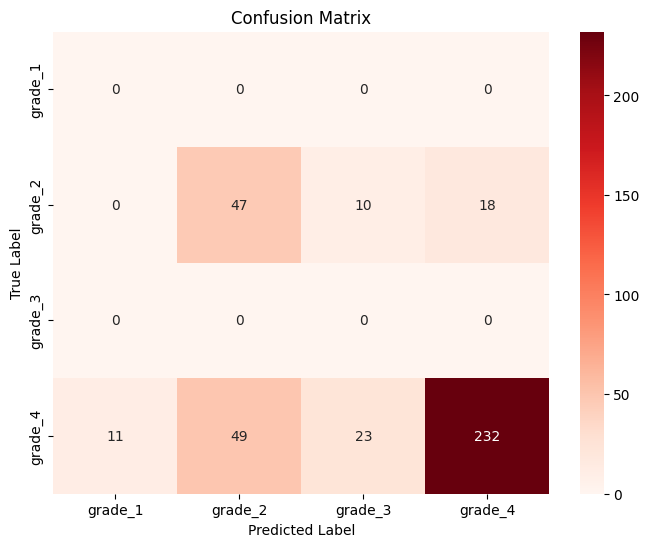

In [ ]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()


##Loss and Accuracy Curve

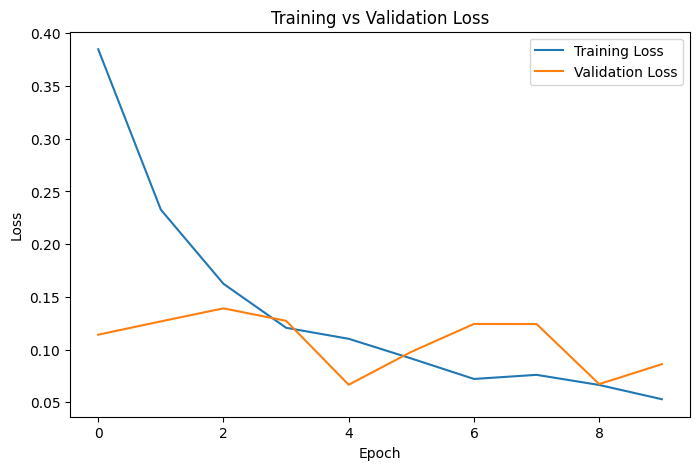

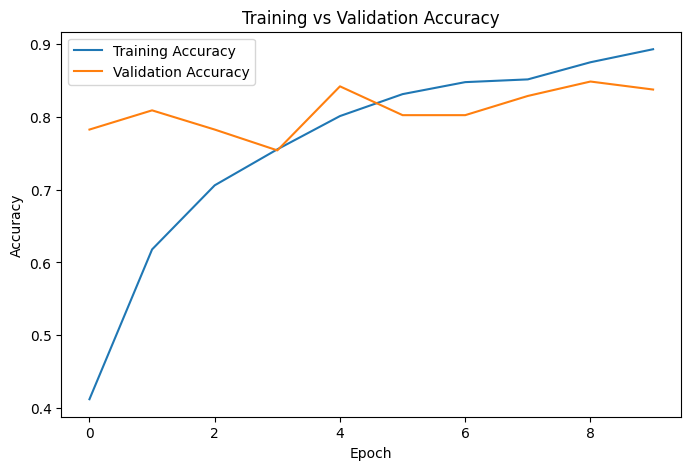

In [ ]:
# Plot the loss
plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()

# Plot the accuracy curve
plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.show()

# Summary of Changes
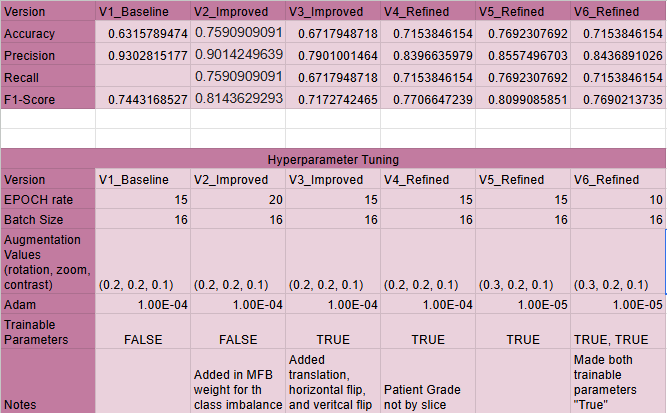